# P4: Visualizing for Trust or Trickery
**Data Story:** How has the fire season shifted over time?
- **Trust:** Alarm dates are starting earlier year over year 
- **Trickery:** Fire size and intensity has increased/decreased year over year


In [1]:
import pandas as pd
df = pd.read_csv("CA_Historic_Fire_Perimeters.csv")

df.head()

,OBJECTID,Year,State,Agency,Unit ID,Fire Name,Local Incident Number,Alarm Date,Containment Date,Cause,...,Management Objective,GIS Calculated Acres,Comments,Complex Name,IRWIN ID,Fire Number (historical use),Complex ID,DECADES,Shape__Area,Shape__Length
0,1,2025.0,CA,CDF,LDF,PALISADES,00000738,1/7/2025 8:00:00 AM,1/31/2025 8:00:00 AM,14,...,1.0,23448.8800,NaN,NaN,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},NaN,NaN,2020-January 2025,1.386518e+08,140231.608232
1,2,2025.0,CA,CDF,LAC,EATON,00009087,1/8/2025 8:00:00 AM,1/31/2025 8:00:00 AM,14,...,1.0,14056.2600,NaN,NaN,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},NaN,NaN,2020-January 2025,8.336393e+07,104933.207224
2,3,2025.0,CA,CDF,ANF,HUGHES,00250270,1/22/2025 8:00:00 AM,1/28/2025 8:00:00 AM,14,...,1.0,10396.8000,NaN,NaN,{994072D2-E154-434A-BB95-6F6C94C40829},NaN,NaN,2020-January 2025,6.216064e+07,96698.599858
3,4,2025.0,CA,CCO,VNC,KENNETH,00003155,1/9/2025 8:00:00 AM,2/4/2025 8:00:00 AM,14,...,1.0,998.7378,from OES Intel 24,NaN,{842FB37B-7AC8-4700-BB9C-028BF753D149},NaN,NaN,2020-January 2025,5.919678e+06,15602.004849
4,5,2025.0,CA,CDF,LDF,HURST,00003294,1/7/2025 8:00:00 AM,1/9/2025 8:00:00 AM,14,...,1.0,831.3855,NaN,NaN,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},NaN,NaN,2020-January 2025,4.946082e+06,16094.217073


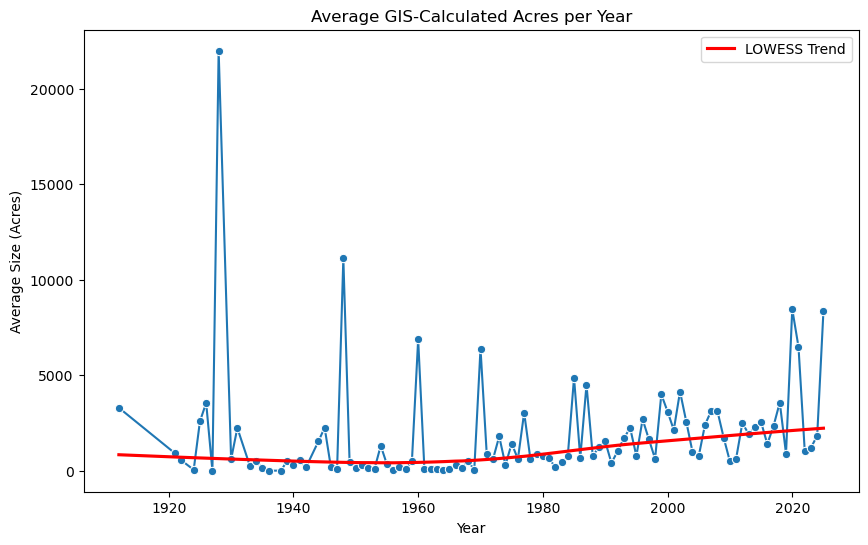

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df['year'] = pd.to_datetime(df['Alarm Date']).dt.year
year_avg = df.groupby('Year')['GIS Calculated Acres'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=year_avg, x='Year', y='GIS Calculated Acres', marker='o')
sns.regplot(data=year_avg, x='Year', y='GIS Calculated Acres', scatter=False,
            lowess=True, color='red', label='LOWESS Trend')
plt.title('Average GIS-Calculated Acres per Year')
plt.xlabel('Year')
plt.ylabel('Average Size (Acres)')
plt.legend()
plt.show()

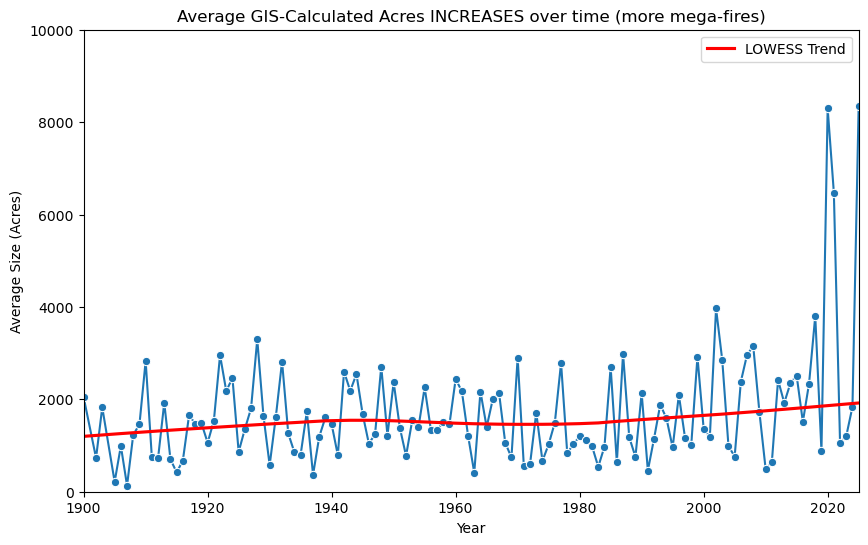

In [12]:
plt.figure(figsize=(10,6))
sns.lineplot(data=year_avg, x='Year', y='GIS Calculated Acres', marker='o')
sns.regplot(data=year_avg, x='Year', y='GIS Calculated Acres', scatter=False,
            lowess=True, color='red', label='LOWESS Trend')
plt.xlim(1900, year_avg['Year'].max())
plt.ylim(0, 10000)
plt.title('Average GIS-Calculated Acres INCREASES over time (more mega-fires)')
plt.xlabel('Year')
plt.ylabel('Average Size (Acres)')
plt.legend()
plt.show()

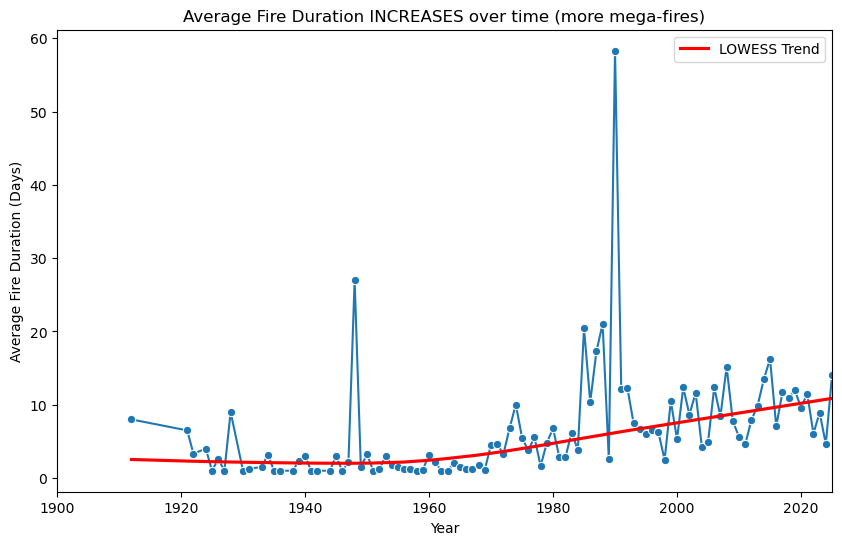

In [4]:
df['Alarm Date'] = pd.to_datetime(df['Alarm Date'])
df['Containment Date'] = pd.to_datetime(df['Containment Date'])

df['fire_duration'] = (df['Containment Date'].dt.floor('d') - df['Alarm Date'].dt.floor('d')).dt.days
df['fire_duration'] = df['fire_duration'].apply(lambda x: max(x, 1))
df = df[df['fire_duration'] >= 0]
duration_avg = df.groupby('Year')['fire_duration'].mean().reset_index()


plt.figure(figsize=(10,6))
sns.lineplot(data=duration_avg, x='Year', y='fire_duration', marker='o')
sns.regplot(data=duration_avg, x='Year', y='fire_duration', scatter=False,
            lowess=True, color='red', label='LOWESS Trend')
plt.xlim(1900, year_avg['Year'].max())
plt.title('Average Fire Duration INCREASES over time (more mega-fires)')
plt.xlabel('Year')
plt.ylabel('Average Fire Duration (Days)')
plt.legend()
plt.show()

# TRICKERY
Same plots but use median instead of mean:
- mean more influenced by extreme fires (larger, last longer) 
- median more influenced by number of small fires
- historically, recorded fewer small fires which artificially raises medians in early years
- better detection and suppression methods in recent years means firefighters are better prepared (a wildfire may take less time to contain and burn fewer acres than that same wildfire in the past)
- criteria to be included in this dataset changed over time (current: ≥10 acres timber, ≥50 acres brush, or ≥300 acres grass and/or ≥3 damaged/destroyed residential or commercial structures, and/or caused ≥1 fatality)
    - (1979) added ≥3000 hours of Cal FIRE personnel time to suppress as possible qualifying criterion
    - (1981) added 1500 acres agricultural products as possible qualifying criterion
    - (1991) added ≥$300,000 worth of damage criteria as possible qualifying criterion
    - (1992) 3000 hours Cal FIRE personnel hours criterion removed, "≥3 structures destroyed" replaces "≥3 residential or ≥1 commercial structure"
    - (2006) ≥300 acres and burned ≥30 acres timber, ≥300 acres brush, ≥1500 acres woodland/grass/agricultural products, ≥ 3 structures destroyed, or ≥$300,000 damage loss
    - (2008) ≥300 acres
    - (2010) ≥50 acres brush changed to ≥30 acres brush

**Conclusions:** 
- average GIS-calculated acres decreases over time
- fire duration decreases over time

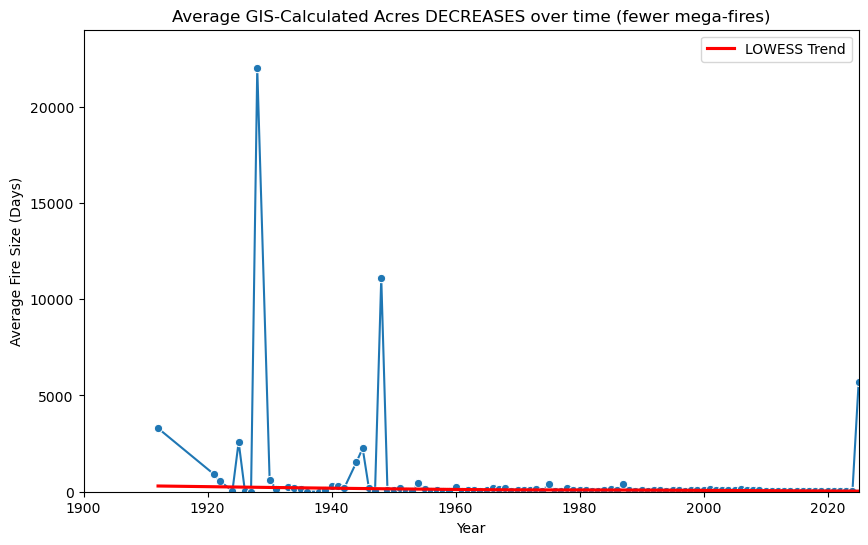

In [11]:
# TRICKERY
# use median instead of mean—fires burn fewer acres in recent years compared to past
# historically, recorded fewer small to medium sized fires (raises early medians)
year_median = df.groupby('Year')['GIS Calculated Acres'].median().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=year_median, x='Year', y='GIS Calculated Acres', marker='o')
sns.regplot(data=year_median, x='Year', y='GIS Calculated Acres', scatter=False,
            lowess=True, color='red', label='LOWESS Trend')
plt.xlim(1900, year_median['Year'].max())
plt.ylim(0, 24000)
plt.title('Average GIS-Calculated Acres DECREASES over time (fewer mega-fires)')
plt.xlabel('Year')
plt.ylabel('Average Fire Size (Days)')
plt.legend()
plt.show()

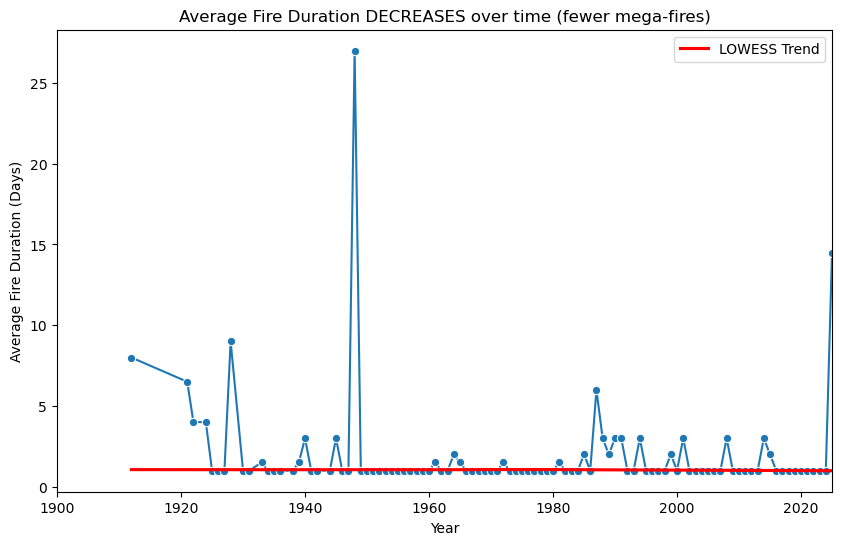

In [6]:
duration_median = df.groupby('Year')['fire_duration'].median().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=duration_median, x='Year', y='fire_duration', marker='o')
sns.regplot(data=duration_median, x='Year', y='fire_duration', scatter=False,
            lowess=True, color='red', label='LOWESS Trend')
plt.xlim(1900, year_median['Year'].max())
plt.title('Average Fire Duration DECREASES over time (fewer mega-fires)')
plt.xlabel('Year')
plt.ylabel('Average Fire Duration (Days)')
plt.legend()
plt.show()

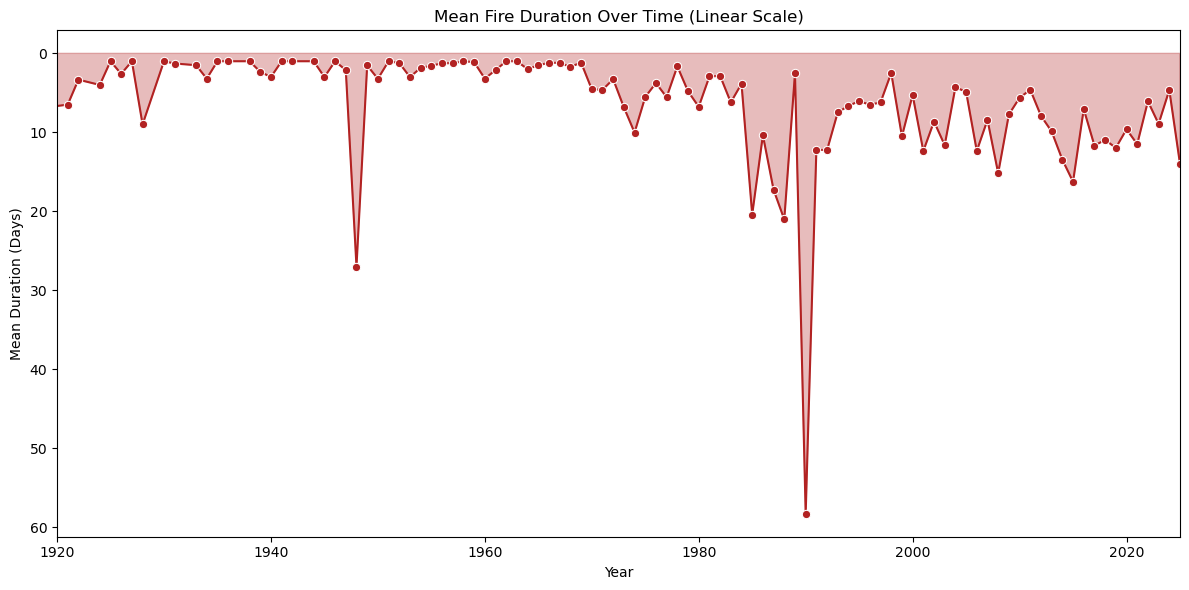

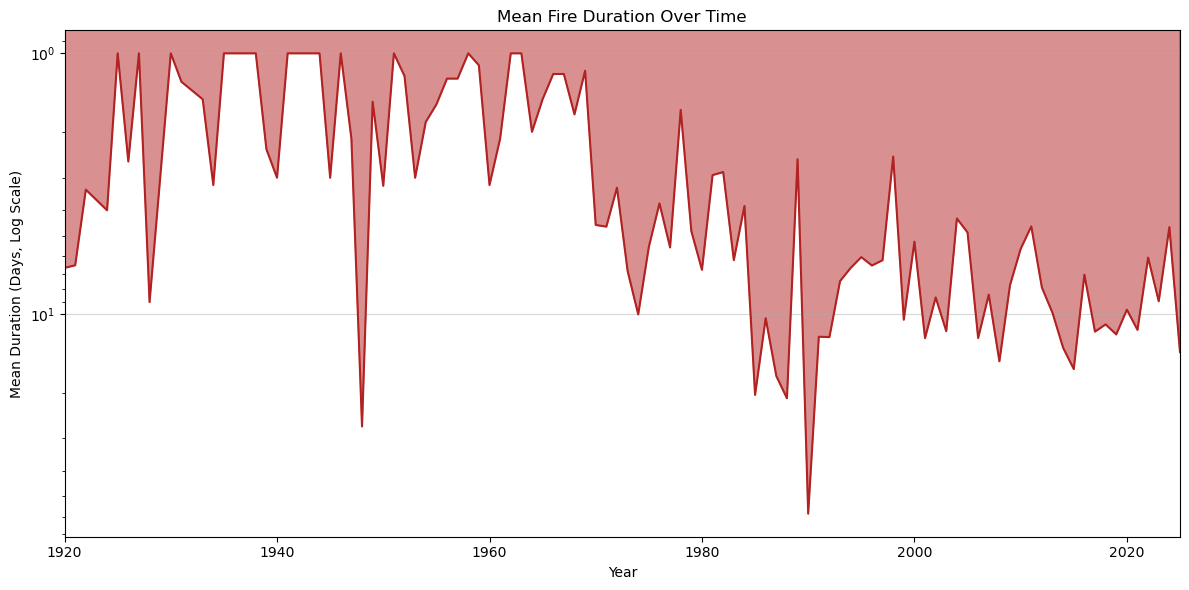

In [ ]:
# Fire duration
# plot on linear vs log y-axis

# LINEAR plot
yearly_mean = df.groupby('Year')['fire_duration'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_mean, x='Year', y='fire_duration',
             marker='o', color='firebrick')
plt.fill_between(yearly_mean['Year'], yearly_mean['fire_duration'], color='firebrick', alpha=.3)
plt.title("Mean Fire Duration Over Time (Linear Scale)")
plt.xlabel("Year")
plt.ylabel("Mean Duration (Days)")
plt.xlim(1920, yearly_mean['Year'].max())
plt.gca().invert_yaxis()
plt.yscale('linear')   
plt.tight_layout()
plt.show()

# LOG plot
plt.figure(figsize=(12,6))

plt.grid(axis='y', linestyle='-', alpha=.5, linewidth=.8, zorder=1)
sns.lineplot(data=yearly_mean, x='Year', y='fire_duration',
            color='firebrick')
plt.fill_between(yearly_mean["Year"], 0, yearly_mean['fire_duration'], color='firebrick', alpha=.5, zorder=1)
plt.title("Mean Fire Duration Over Time")
plt.xlabel("Year")
plt.ylabel("Mean Duration (Days, Log Scale)")
plt.xlim(1920, yearly_mean['Year'].max())
plt.gca().invert_yaxis()
plt.yscale('log')  
plt.tight_layout()
plt.show()

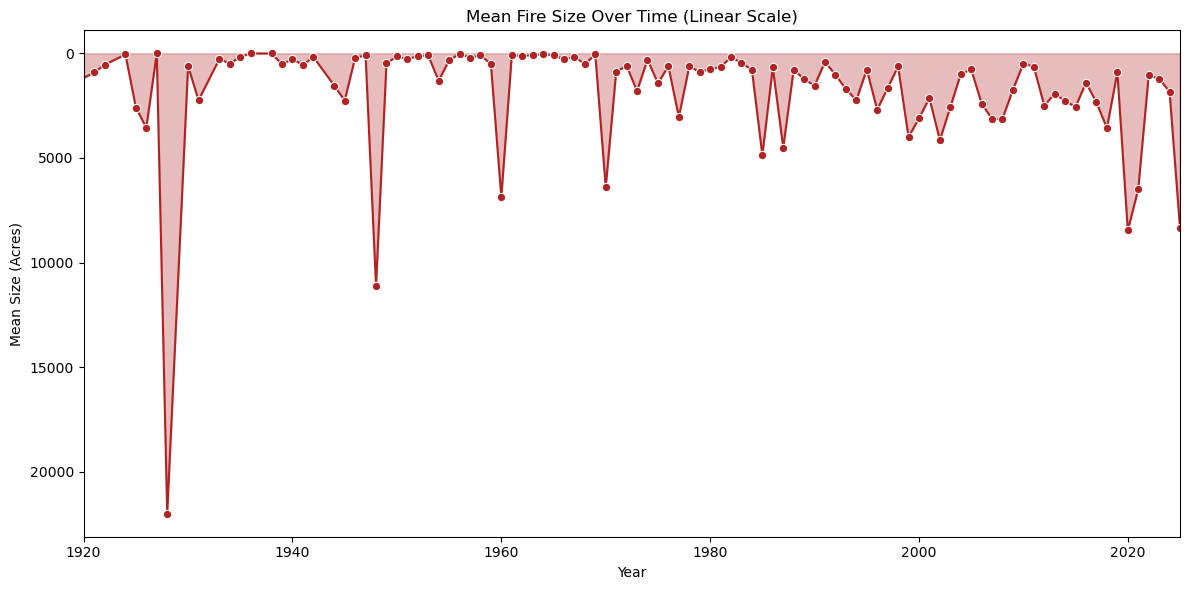

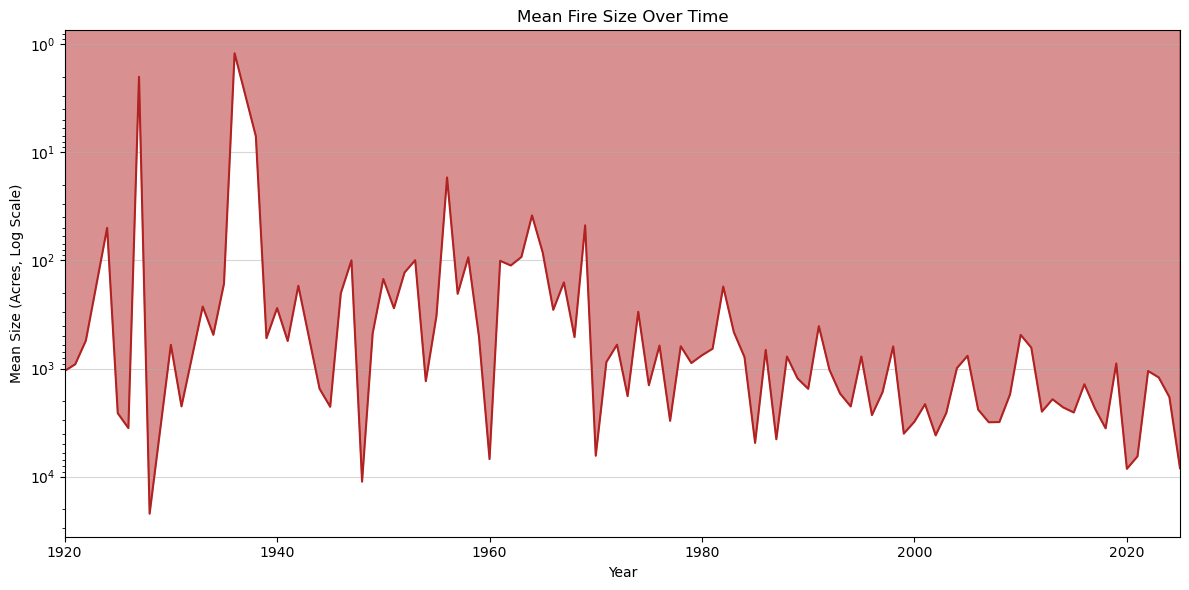

In [ ]:
# Fire size
# plot on linear vs log y-axis

# LINEAR plot
yearly_mean = df.groupby('Year')['GIS Calculated Acres'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_mean, x='Year', y='GIS Calculated Acres',
             marker='o', color='firebrick')
plt.fill_between(yearly_mean['Year'], yearly_mean['GIS Calculated Acres'], color='firebrick', alpha=.3)
plt.title("Mean Fire Size Over Time (Linear Scale)")
plt.xlabel("Year")
plt.ylabel("Mean Size (Acres)")
plt.xlim(1920, yearly_mean['Year'].max())
plt.gca().invert_yaxis()
plt.yscale('linear')   
plt.tight_layout()
plt.show()

# LOG plot
plt.figure(figsize=(12,6))

plt.grid(axis='y', linestyle='-', alpha=.5, linewidth=.8, zorder=1)
sns.lineplot(data=yearly_mean, x='Year', y='GIS Calculated Acres',
            color='firebrick')
plt.fill_between(yearly_mean["Year"], 0, yearly_mean['GIS Calculated Acres'], color='firebrick', alpha=.5, zorder=1)
plt.title("Mean Fire Size Over Time")
plt.xlabel("Year")
plt.ylabel("Mean Size (Acres, Log Scale)")
plt.xlim(1920, yearly_mean['Year'].max())
plt.gca().invert_yaxis()
plt.yscale('log')  
plt.tight_layout()
plt.show()